# PVOL vs DVOL — Time Series Comparison

Charts PVOL (Polymarket-implied vol) against DVOL (Deribit's published index) day-by-day
across two contract months with very different BTC regimes:

| Contract | Regime | Sample window |
|---|---|---|
| November 2025 | Volatile / bearish | Nov 1 – Nov 23 (23 days) |
| February 2026 | Moderate | Feb 1 – Feb 21 (21 days) |

Both windows stop 7 days before expiry to avoid near-expiry noise (T → 0 instability).

**Pipeline:** identical to `pvol_model_test.ipynb` — logistic smoothing → clean ladder →
touch-band-weighted PVOL. One snapshot per day at midnight UTC.


In [45]:
%matplotlib inline
import re, json, time
import numpy as np
import pandas as pd
import requests
from scipy.stats import norm
from scipy.optimize import curve_fit
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
print('imports ok')


imports ok


In [46]:
def fetch_spot_range(start: datetime, end: datetime) -> dict:
    """Fetch BTC daily spot prices for a date range. One API call; no per-date rate limiting.
    Returns {midnight_utc_datetime: float}.
    For ranges <90d CoinGecko returns hourly data; resampled to daily here.
    """
    r = requests.get(
        'https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range',
        params={'vs_currency': 'usd',
                'from': int(start.timestamp()),
                'to': int(end.timestamp()),
                'precision': '2'},
        headers={'accept': 'application/json'},
    )
    r.raise_for_status()
    prices = r.json()['prices']  # [[ts_ms, price], ...]
    # Resample to daily: keep entry closest to midnight UTC per calendar day
    daily = {}
    for ts_ms, price in prices:
        dt = datetime.fromtimestamp(ts_ms / 1000, tz=timezone.utc)
        midnight = dt.replace(hour=0, minute=0, second=0, microsecond=0)
        if midnight not in daily or \
                abs((dt - midnight).total_seconds()) < abs((daily[midnight][0] - midnight).total_seconds()):
            daily[midnight] = (dt, price)
    return {d: p for d, (_, p) in daily.items()}

print('fetch_spot_range defined')

fetch_spot_range defined


---
## PVOL Pipeline Functions

Reused from `pvol_model_test.ipynb`. One function per pipeline step.


In [47]:
EPSILON = 0.0001

def get_p_hat(yes_price, yes_bid=None, yes_ask=None):
    raw = (yes_bid + yes_ask) / 2.0 if (yes_bid is not None and yes_ask is not None) else yes_price
    return float(np.clip(raw, EPSILON, 1.0 - EPSILON))

def fit_logistic(probs: dict, spot: float) -> dict:
    """Fit P(d) = 1/(1+exp(a+b*d)). Falls back to raw probs if fit fails or < 3 rungs."""
    if len(probs) < 3:
        return probs
    strikes = np.array(list(probs.keys()), dtype=float)
    p_vals  = np.array(list(probs.values()), dtype=float)
    d_vals  = np.abs(np.log(strikes / spot))
    def logistic(d, a, b): return 1.0 / (1.0 + np.exp(a + b * d))
    try:
        popt, _ = curve_fit(logistic, d_vals, p_vals, p0=[-0.5, 6.0],
                            bounds=([-5., 0.], [5., 12.]), maxfev=10_000)
        a, b = popt
        return {h: float(np.clip(logistic(abs(np.log(h / spot)), a, b), EPSILON, 1. - EPSILON))
                for h in probs}
    except Exception:
        return probs

def clean_ladder(probs: dict) -> dict:
    """Drop rungs at and beyond the first monotonicity violation."""
    clean, prev_p = {}, 1.0
    for h, p in probs.items():
        if p >= prev_p:
            break
        clean[h] = p
        prev_p = p
    return clean

def compute_pvol_snapshot(upside_raw: dict, downside_raw: dict, spot: float, T: float) -> dict:
    """
    Full pipeline for one snapshot.
    Returns {pvol_up, pvol_down, pvol_combined, n_rungs}. All vols are annualized decimals.
    """
    if T <= 0 or len(upside_raw) < 2 or len(downside_raw) < 2:
        return {'pvol_up': None, 'pvol_down': None, 'pvol_combined': None, 'n_rungs': 0}

    up_p   = {h: get_p_hat(p) for h, p in upside_raw.items()}
    down_p = {h: get_p_hat(p) for h, p in downside_raw.items()}
    up_s   = fit_logistic(up_p,   spot)
    down_s = fit_logistic(down_p, spot)
    up_c   = clean_ladder(dict(sorted(up_s.items())))
    down_c = clean_ladder(dict(sorted(down_s.items(), reverse=True)))

    def _side_pvol(probs_clean):
        rows = []
        for h, p in probs_clean.items():
            sigma = abs(np.log(h / spot)) / (np.sqrt(T) * abs(norm.ppf(p / 2.0)))
            rows.append((p, sigma))
        if len(rows) < 2:
            return None
        ps = np.array([r[0] for r in rows])
        ss = np.array([r[1] for r in rows])
        w = np.empty(len(ps))
        for i in range(len(ps) - 1): w[i] = ps[i] - ps[i + 1]
        w[-1] = ps[-1]
        return float((w * ss).sum() / w.sum())

    pvol_up   = _side_pvol(up_c)
    pvol_down = _side_pvol(down_c)

    # Combined: all rungs sorted by log-distance, reweighted
    all_rungs = []
    for h, p in {**up_c, **down_c}.items():
        d = abs(np.log(h / spot))
        sigma = d / (np.sqrt(T) * abs(norm.ppf(p / 2.0)))
        all_rungs.append((d, p, sigma))
    all_rungs.sort()

    pvol_combined = None
    if len(all_rungs) >= 2:
        ps = np.array([r[1] for r in all_rungs])
        ss = np.array([r[2] for r in all_rungs])
        w = np.empty(len(ps))
        for i in range(len(ps) - 1): w[i] = ps[i] - ps[i + 1]
        w[-1] = ps[-1]
        pvol_combined = float((w * ss).sum() / w.sum())

    return {'pvol_up': pvol_up, 'pvol_down': pvol_down,
            'pvol_combined': pvol_combined, 'n_rungs': len(all_rungs)}

print('pipeline functions loaded')


pipeline functions loaded


---
## Contract Setup

Fetch event metadata for both months, parse markets, and build date ranges.


In [48]:
GAMMA = "https://gamma-api.polymarket.com"
CLOB  = "https://clob.polymarket.com"

def parse_strike(question: str) -> int | None:
    m = re.search(r"\$([0-9][0-9,]*)([kK])?", question)
    if not m:
        return None
    digits = int(m.group(1).replace(",", ""))
    if m.group(2):
        digits *= 1000
    return digits

def has_date_qualifier(question: str) -> bool:
    return bool(re.search(r"after|before|starting|from\s+", question, re.IGNORECASE))

def parse_markets(event: dict) -> tuple[dict, dict]:
    """Returns (upside, downside): {strike: token_id}"""
    up, dn = {}, {}
    for m in event["markets"]:
        q = m["question"]
        if has_date_qualifier(q):
            continue
        strike = parse_strike(q)
        if strike is None:
            continue
        token_id = json.loads(m["clobTokenIds"])[0]
        q_lower = q.lower()
        if "reach" in q_lower:
            up[strike] = token_id
        elif "dip" in q_lower:
            dn[strike] = token_id
    return up, dn

spot_cache = {}

CONTRACTS = {}
for key, slug, label, color in [
    ("nov2025", "what-price-will-bitcoin-hit-in-november-2025", "November 2025", "#e74c3c"),
    ("feb2026", "what-price-will-bitcoin-hit-in-february-2026", "February 2026", "#3498db"),
]:
    event  = requests.get(f"{GAMMA}/events/slug/{slug}").json()
    expiry = datetime.fromisoformat(event["endDate"].replace("Z", "+00:00"))
    up_m, dn_m = parse_markets(event)

    # endDate is the 1st of the following month, so step back into the contract month first
    start  = (expiry - timedelta(days=15)).replace(day=1, hour=0, minute=0, second=0, microsecond=0)
    cutoff = expiry - timedelta(days=7)
    dates  = []
    d = start
    while d <= cutoff:
        dates.append(d)
        d += timedelta(days=1)

    # Fetch day-1 spot via range call and filter cross-side markets
    setup_range = fetch_spot_range(dates[0], dates[0] + timedelta(days=2))
    spot_day1 = setup_range.get(dates[0])
    spot_cache[dates[0]] = spot_day1
    up_m = {h: tok for h, tok in up_m.items() if h > spot_day1}
    dn_m = {h: tok for h, tok in dn_m.items() if h < spot_day1}

    CONTRACTS[key] = dict(slug=slug, label=label, color=color,
                          expiry=expiry, up_markets=up_m, down_markets=dn_m, dates=dates)

    print(f"{label}:  expiry {expiry.date()}  |  {len(dates)} sample days  |"
          f"  {len(up_m)} upside + {len(dn_m)} downside markets  (spot day-1: ${spot_day1:,.0f})")

November 2025:  expiry 2025-12-01  |  24 sample days  |  10 upside + 10 downside markets  (spot day-1: $109,574)
February 2026:  expiry 2026-03-01  |  22 sample days  |  11 upside + 9 downside markets  (spot day-1: $78,642)


In [49]:
# ── Verify contract setup ────────────────────────────────────────────────────
assert len(CONTRACTS) == 2, 'Expected 2 contracts'
for key, c in CONTRACTS.items():
    assert len(c['dates']) > 0, f"{c['label']}: no sample dates"
    assert len(c['up_markets']) >= 3, f"{c['label']}: too few upside markets"
    assert len(c['down_markets']) >= 3, f"{c['label']}: too few downside markets"
    spot_d1 = spot_cache[c['dates'][0]]
    assert spot_d1 is not None, f"{c['label']}: day-1 spot missing"
    assert all(h > spot_d1 for h in c['up_markets']), f"{c['label']}: cross-side upside strikes present"
    assert all(h < spot_d1 for h in c['down_markets']), f"{c['label']}: cross-side downside strikes present"
    print(f"{c['label']}:  {len(c['dates'])} days  |  "
          f"{len(c['up_markets'])} up {sorted(c['up_markets'].keys())}")
    print(f"{'':14}{len(c['down_markets'])} dn {sorted(c['down_markets'].keys())}")
    print(f"{'':14}spot day-1 ${spot_d1:,.0f}")
print('contract setup OK')


November 2025:  24 days  |  10 up [110000, 115000, 120000, 125000, 130000, 135000, 140000, 145000, 150000, 200000]
              10 dn [60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000, 100000, 105000]
              spot day-1 $109,574
February 2026:  22 days  |  11 up [80000, 85000, 90000, 95000, 100000, 105000, 110000, 115000, 120000, 125000, 150000]
              9 dn [35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000]
              spot day-1 $78,642
contract setup OK


---
## Data Fetch — Polymarket

For each contract, fetch the full-month price history for every strike token at hourly
fidelity (`fidelity=60`). One API call per token; prices are resampled to midnight UTC
when computing PVOL. This is ~2 × 20 calls instead of 44 × 20 = 880.


In [50]:
def fetch_price_history(token_id: str) -> list:
    """Fetch full price history for a token. Works on both active and expired markets."""
    r = requests.get(f'{CLOB}/prices-history', params=dict(
        market=token_id,
        interval='all',
        fidelity=1440,
    ))
    if r.status_code == 400:
        print(f"  WARNING: 400 for token {token_id[:12]}... skipping")
        return []
    r.raise_for_status()
    return r.json().get("history", [])

for key, c in CONTRACTS.items():
    all_tokens = {**c['up_markets'], **c['down_markets']}
    print(f"Fetching {c['label']} ({len(all_tokens)} tokens)...", end='', flush=True)
    price_data = {}
    for strike, tok in all_tokens.items():
        price_data[tok] = fetch_price_history(tok)
    c['price_data'] = price_data
    n_pts = sum(len(v) for v in price_data.values())
    print(f' {n_pts:,} total price points, done')

print('Polymarket fetch complete.')


Fetching November 2025 (20 tokens)... 473 total price points, done
Fetching February 2026 (20 tokens)... 474 total price points, done
Polymarket fetch complete.


In [51]:
# ── Verify Polymarket price histories ───────────────────────────────────────
for key, c in CONTRACTS.items():
    print(f"\n{c['label']}:")
    empty = []
    for side, mkts in [('up', c['up_markets']), ('dn', c['down_markets'])]:
        for strike, tok in sorted(mkts.items()):
            pts = len(c['price_data'].get(tok, []))
            flag = '  ⚠ NO DATA' if pts == 0 else ''
            print(f"  {side} ${strike:>7,}: {pts:>3} pts{flag}")
            if pts == 0:
                empty.append((c['label'], side, strike))
    if not empty:
        print(f'  all tokens have data')
    else:
        print(f'  WARNING: {len(empty)} token(s) have no price data')
print('Polymarket fetch verification done')



November 2025:
  up $110,000:   0 pts  ⚠ NO DATA
  up $115,000:  30 pts
  up $120,000:  30 pts
  up $125,000:  30 pts
  up $130,000:  30 pts
  up $135,000:  30 pts
  up $140,000:  30 pts
  up $145,000:  30 pts
  up $150,000:  30 pts
  up $200,000:  30 pts
  dn $ 60,000:  30 pts
  dn $ 65,000:  30 pts
  dn $ 70,000:  30 pts
  dn $ 75,000:  30 pts
  dn $ 80,000:  30 pts
  dn $ 85,000:  20 pts
  dn $ 90,000:  17 pts
  dn $ 95,000:  13 pts
  dn $100,000:   0 pts  ⚠ NO DATA
  dn $105,000:   3 pts

February 2026:
  up $ 80,000:  22 pts
  up $ 85,000:  26 pts
  up $ 90,000:  25 pts
  up $ 95,000:  29 pts
  up $100,000:  29 pts
  up $105,000:  29 pts
  up $110,000:  29 pts
  up $115,000:  29 pts
  up $120,000:  29 pts
  up $125,000:  29 pts
  up $150,000:  25 pts
  dn $ 35,000:  29 pts
  dn $ 40,000:  29 pts
  dn $ 45,000:  23 pts
  dn $ 50,000:  29 pts
  dn $ 55,000:  29 pts
  dn $ 60,000:  22 pts
  dn $ 65,000:   5 pts
  dn $ 70,000:   5 pts
  dn $ 75,000:   2 pts
  all tokens have data
Pol

---
## Data Fetch — DVOL (Deribit)

One call per contract month; hourly candles for the full period.
We use the **close** of each candle as the DVOL snapshot value.


In [52]:
def fetch_dvol_series(start: datetime, end: datetime) -> pd.Series:
    """Hourly DVOL for BTC. Returns Series[datetime -> float] in decimal (0.48 = 48%)."""
    r = requests.get(
        'https://www.deribit.com/api/v2/public/get_volatility_index_data',
        params=dict(currency='BTC',
                    start_timestamp=int(start.timestamp() * 1000),
                    end_timestamp=int(end.timestamp()   * 1000),
                    resolution=3600),
    )
    r.raise_for_status()
    data = r.json()['result']['data']
    idx  = [datetime.fromtimestamp(row[0] / 1000, tz=timezone.utc) for row in data]
    vals = [row[4] / 100.0 for row in data]  # close, percent -> decimal
    return pd.Series(vals, index=idx, name='dvol')

dvol_all = {}
for key, c in CONTRACTS.items():
    dvol_all[key] = fetch_dvol_series(c['dates'][0], c['expiry'])
    s = dvol_all[key]
    print(f"{c['label']}: {len(s)} hourly readings  |  "
          f"range {s.min():.1%} – {s.max():.1%}  |  mean {s.mean():.1%}")


November 2025: 726 hourly readings  |  range 42.8% – 61.7%  |  mean 48.9%
February 2026: 678 hourly readings  |  range 45.6% – 89.8%  |  mean 53.7%


In [53]:
# ── Verify DVOL series ──────────────────────────────────────────────────────
for key, c in CONTRACTS.items():
    s = dvol_all[key]
    assert len(s) > 0, f"{c['label']}: empty DVOL series"
    assert s.index[0] <= pd.Timestamp(c['dates'][0]), \
        f"{c['label']}: DVOL series starts after contract start"
    print(f"{c['label']}: {len(s)} hourly pts  |  "
          f"{s.index[0].date()} to {s.index[-1].date()}  |  "
          f"{s.min():.1%} – {s.max():.1%}  mean {s.mean():.1%}")
print('DVOL verification OK')


November 2025: 726 hourly pts  |  2025-11-01 to 2025-12-01  |  42.8% – 61.7%  mean 48.9%
February 2026: 678 hourly pts  |  2026-02-01 to 2026-03-01  |  45.6% – 89.8%  mean 53.7%
DVOL verification OK


---
## Data Fetch — BTC Spot (CoinGecko)

`fetch_spot_range` is defined above. Fetches all daily closing prices in one range call per
contract (`market_chart/range`), matching the DVOL fetch pattern. No per-date rate limiting.

In [54]:
for key, c in CONTRACTS.items():
    spot_range = fetch_spot_range(c['dates'][0], c['dates'][-1] + timedelta(days=1))
    for dt in c['dates']:
        if dt not in spot_cache:
            spot_cache[dt] = spot_range.get(dt)
    n_ok = sum(1 for d in c['dates'] if spot_cache.get(d) is not None)
    print(f"{c['label']}: {n_ok}/{len(c['dates'])} dates resolved")

print(f"\nSpot cache total: {len(spot_cache)} dates")
missing = [d.date() for d, v in spot_cache.items() if v is None]
print(f"Missing: {missing}" if missing else "No missing dates.")

November 2025: 24/24 dates resolved
February 2026: 22/22 dates resolved

Spot cache total: 46 dates
No missing dates.


In [55]:
# ── Verify BTC spot cache ───────────────────────────────────────────────────
all_dates = sorted({d for c in CONTRACTS.values() for d in c['dates']})
missing = [dt for dt in all_dates if spot_cache.get(dt) is None]
assert not missing, f'Missing spot for: {[d.date() for d in missing]}'
print(f'Spot cache: {len(spot_cache)} dates, all present')

for dt in sorted(spot_cache):
    print(f'{str(dt.date()):<12}  ${spot_cache[dt]:>9,.0f}')


Spot cache: 46 dates, all present
2025-11-01    $  109,574
2025-11-02    $  110,067
2025-11-03    $  110,650
2025-11-04    $  106,521
2025-11-05    $  101,481
2025-11-06    $  103,878
2025-11-07    $  101,323
2025-11-08    $  103,396
2025-11-09    $  102,290
2025-11-10    $  104,710
2025-11-11    $  105,952
2025-11-12    $  103,112
2025-11-13    $  101,634
2025-11-14    $   99,480
2025-11-15    $   94,456
2025-11-16    $   95,508
2025-11-17    $   94,411
2025-11-18    $   92,037
2025-11-19    $   92,820
2025-11-20    $   91,408
2025-11-21    $   86,650
2025-11-22    $   85,088
2025-11-23    $   84,676
2025-11-24    $   86,784
2026-02-01    $   78,642
2026-02-02    $   76,907
2026-02-03    $   78,665
2026-02-04    $   75,650
2026-02-05    $   73,023
2026-02-06    $   62,822
2026-02-07    $   70,546
2026-02-08    $   69,271
2026-02-09    $   70,288
2026-02-10    $   70,124
2026-02-11    $   68,787
2026-02-12    $   66,994
2026-02-13    $   66,192
2026-02-14    $   68,849
2026-02-15    $ 

---
## Compute PVOL per Day

For each (contract, date): assemble the ladder from hourly price histories,
run the full pipeline, look up DVOL from the hourly series, store in a DataFrame.


In [57]:
def get_p_at_date(tok: str, price_data: dict, target_dt: datetime,
                  window_hours: int = 4) -> float | None:
    """Closest price to midnight UTC on target_dt, within window_hours."""
    hist = price_data.get(tok, [])
    if not hist:
        return None
    target_unix = int(target_dt.timestamp())
    window = window_hours * 3600
    best_p, best_d = None, float('inf')
    for row in hist:
        delta = abs(row['t'] - target_unix)
        if delta <= window and delta < best_d:
            best_p, best_d = row['p'], delta
    return best_p

records = []
for key, c in CONTRACTS.items():
    for dt in c['dates']:
        spot = spot_cache.get(dt)
        if spot is None:
            continue
        T = (c['expiry'] - dt).total_seconds() / (365.25 * 86400)

        up_raw = {h: p for h in c['up_markets']
                  if h > spot and (p := get_p_at_date(c['up_markets'][h], c['price_data'], dt)) is not None}
        dn_raw = {h: p for h in c['down_markets']
                  if h < spot and (p := get_p_at_date(c['down_markets'][h], c['price_data'], dt)) is not None}

        if len(up_raw) < 2 or len(dn_raw) < 2:
            continue

        pv = compute_pvol_snapshot(
            dict(sorted(up_raw.items())),
            dict(sorted(dn_raw.items(), reverse=True)),
            spot, T,
        )

        # DVOL: closest hourly reading to midnight
        # dt is already timezone-aware; pd.Timestamp preserves tzinfo without tz= arg
        dv_s  = dvol_all[key]
        diffs = abs(dv_s.index - pd.Timestamp(dt))
        dv    = float(dv_s.iloc[diffs.argmin()])

        records.append(dict(
            contract=key, label=c['label'], color=c['color'],
            date=dt.date(), dt=dt,
            spot=spot, T_days=round(T * 365.25, 1),
            pvol=pv['pvol_combined'], pvol_up=pv['pvol_up'], pvol_down=pv['pvol_down'],
            dvol=dv,
            gap=(pv['pvol_combined'] - dv) if pv['pvol_combined'] else None,
            n_rungs=pv['n_rungs'],
        ))

df = pd.DataFrame(records)
df['dt'] = pd.to_datetime(df['dt'])

print(df[['contract', 'date', 'spot', 'pvol', 'dvol', 'gap', 'n_rungs']]
      .assign(spot=df['spot'].map('${:,.0f}'.format),
              pvol=df['pvol'].map('{:.1%}'.format),
              dvol=df['dvol'].map('{:.1%}'.format),
              gap=df['gap'].map('{:+.1%}'.format))
      .to_string(index=False))

contract       date     spot  pvol  dvol    gap  n_rungs
 nov2025 2025-11-02 $110,067 42.0% 43.6%  -1.6%       18
 nov2025 2025-11-03 $110,650 42.7% 43.9%  -1.1%       18
 nov2025 2025-11-04 $106,521 35.4% 45.9% -10.5%       18
 nov2025 2025-11-05 $101,481 42.7% 48.5%  -5.8%       17
 nov2025 2025-11-06 $103,878 45.4% 46.5%  -1.1%       17
 nov2025 2025-11-07 $101,323 43.3% 47.4%  -4.1%       17
 nov2025 2025-11-08 $103,396 43.7% 44.9%  -1.2%       17
 nov2025 2025-11-09 $102,290 42.6% 45.1%  -2.5%       17
 nov2025 2025-11-10 $104,710 46.3% 44.8%  +1.5%       17
 nov2025 2025-11-11 $105,952 45.0% 44.3%  +0.7%       17
 nov2025 2025-11-12 $103,112 45.8% 46.6%  -0.8%       17
 nov2025 2025-11-13 $101,634 45.5% 45.3%  +0.1%       17
 nov2025 2025-11-14  $99,480 45.2% 46.4%  -1.2%       17
 nov2025 2025-11-15  $94,456 46.8% 49.4%  -2.6%       16
 nov2025 2025-11-16  $95,508 44.6% 48.5%  -3.9%       16
 nov2025 2025-11-17  $94,411 48.5% 48.9%  -0.4%       16
 nov2025 2025-11-18  $92,037 47

---
## Chart 1 — Per-Month PVOL vs DVOL

Each subplot shows one contract month. PVOL (solid) and DVOL (dashed) on the left axis;
BTC spot on the right axis (dotted, gray). Shaded regions show when PVOL diverges from DVOL.


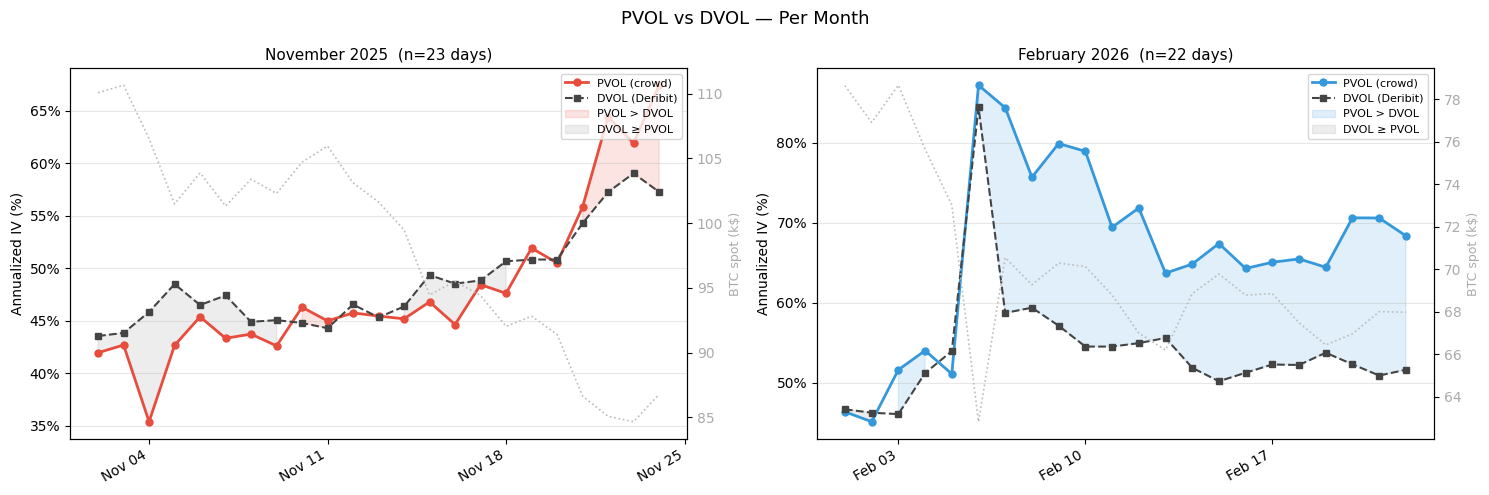

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('PVOL vs DVOL — Per Month', fontsize=13)

for ax, (key, c) in zip(axes, CONTRACTS.items()):
    sub = df[df['contract'] == key].copy()

    ax.plot(sub['dt'], sub['pvol'] * 100, 'o-', color=c['color'],
            lw=2, ms=5, label='PVOL (crowd)')
    ax.plot(sub['dt'], sub['dvol'] * 100, 's--', color='#444444',
            lw=1.5, ms=4, label='DVOL (Deribit)')

    pvol_arr = sub['pvol'].values
    dvol_arr = sub['dvol'].values
    ax.fill_between(sub['dt'], pvol_arr * 100, dvol_arr * 100,
                    where=pvol_arr > dvol_arr,
                    color=c['color'], alpha=0.15, label='PVOL > DVOL')
    ax.fill_between(sub['dt'], pvol_arr * 100, dvol_arr * 100,
                    where=pvol_arr <= dvol_arr,
                    color='#888888', alpha=0.15, label='DVOL ≥ PVOL')

    ax2 = ax.twinx()
    ax2.plot(sub['dt'], sub['spot'] / 1000, color='#bbbbbb', lw=1.2,
             linestyle=':', label='BTC (k$)')
    ax2.set_ylabel('BTC spot (k$)', color='#aaaaaa', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='#aaaaaa')

    ax.set_title(f"{c['label']}  (n={len(sub)} days)", fontsize=11)
    ax.set_ylabel('Annualized IV (%)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---
## Chart 2 — Combined Timeline + Gap

Both months on a single timeline (the gap between Nov 2025 and Feb 2026 is real —
there is no Polymarket contract covering December or January in our dataset).

The lower panel shows the gap (PVOL − DVOL) in percentage points. Green bars = PVOL > DVOL
(crowd pricing more vol than Deribit); gray bars = opposite.


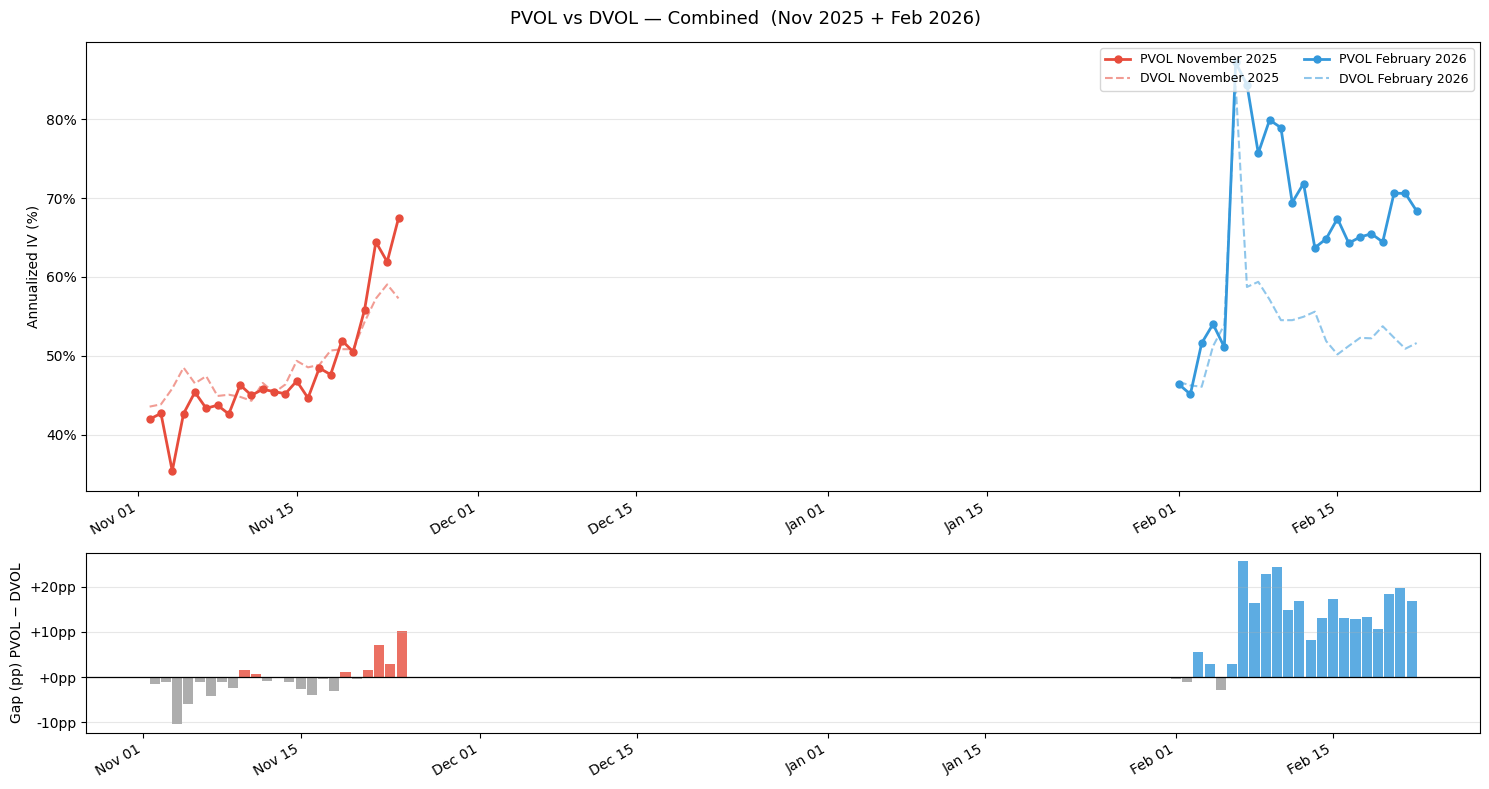

In [60]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8),
                                gridspec_kw={'height_ratios': [3, 1.2]},
                                sharex=False)
fig.suptitle('PVOL vs DVOL — Combined  (Nov 2025 + Feb 2026)', fontsize=13)

for key, c in CONTRACTS.items():
    sub = df[df['contract'] == key]
    ax1.plot(sub['dt'], sub['pvol'] * 100, 'o-', color=c['color'],
             lw=2, ms=5, label=f"PVOL {c['label']}")
    ax1.plot(sub['dt'], sub['dvol'] * 100, '--', color=c['color'],
             lw=1.5, alpha=0.55, label=f"DVOL {c['label']}")

ax1.set_ylabel('Annualized IV (%)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax1.legend(fontsize=9, ncol=2, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

for key, c in CONTRACTS.items():
    sub = df[df['contract'] == key].dropna(subset=['gap'])
    gap_pct = sub['gap'] * 100
    bar_colors = [c['color'] if g > 0 else '#999999' for g in gap_pct]
    ax2.bar(sub['dt'], gap_pct, color=bar_colors, alpha=0.8, width=0.9)

ax2.axhline(0, color='black', lw=0.9)
ax2.set_ylabel('Gap (pp) PVOL − DVOL')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:+.0f}pp'))
ax2.grid(axis='y', alpha=0.3)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


---
## Summary Statistics


In [61]:
for key, c in CONTRACTS.items():
    sub = df[df['contract'] == key].dropna(subset=['pvol', 'dvol', 'gap'])
    print(f"{'='*50}")
    print(f"  {c['label']}  (n={len(sub)} days)")
    print(f"{'='*50}")
    print(f"  BTC spot      : ${sub['spot'].min():,.0f} – ${sub['spot'].max():,.0f}")
    print(f"  PVOL          : {sub['pvol'].min():.1%} – {sub['pvol'].max():.1%}  "
          f"(mean {sub['pvol'].mean():.1%})")
    print(f"  DVOL          : {sub['dvol'].min():.1%} – {sub['dvol'].max():.1%}  "
          f"(mean {sub['dvol'].mean():.1%})")
    print(f"  Gap (PVOL-DVOL): {sub['gap'].min():+.1%} – {sub['gap'].max():+.1%}  "
          f"(mean {sub['gap'].mean():+.1%})")
    days_pvol_above = (sub['gap'] > 0).sum()
    print(f"  Days PVOL > DVOL: {days_pvol_above}/{len(sub)}")
    print()


  November 2025  (n=23 days)
  BTC spot      : $84,676 – $110,650
  PVOL          : 35.4% – 67.4%  (mean 48.0%)
  DVOL          : 43.6% – 59.1%  (mean 48.7%)
  Gap (PVOL-DVOL): -10.5% – +10.2%  (mean -0.6%)
  Days PVOL > DVOL: 8/23

  February 2026  (n=22 days)
  BTC spot      : $62,822 – $78,665
  PVOL          : 45.1% – 87.2%  (mean 66.4%)
  DVOL          : 46.1% – 84.4%  (mean 54.1%)
  Gap (PVOL-DVOL): -2.8% – +25.6%  (mean +12.3%)
  Days PVOL > DVOL: 19/22



---
## Conclusions

*(Fill in after running — guiding questions below.)*

**Vol level comparison**
- In November 2025 (bearish regime), were both PVOL and DVOL elevated? Did they move together?
- In February 2026 (moderate regime), were they both lower? More tightly coupled?

**Gap behavior**
- Was the gap (PVOL − DVOL) predominantly positive or negative in each month?
- A persistent positive gap in November would suggest the Polymarket crowd anticipated more
  volatility than Deribit's options market — potentially pricing in tail risk that options
  desks were slow to reflect.
- A near-zero gap in February would suggest convergence between crowds during calmer markets.

**Regime sensitivity**
- Did PVOL track DVOL more tightly in one regime vs the other?
- A wider, more erratic gap in November would suggest that Polymarket probabilities decouple
  from the options market during stress — either because retail participants overreact, or
  because Polymarket's barrier-option framing captures a different risk dimension than
  Deribit's variance swap methodology.

**Upside vs downside skew** *(pvol_up vs pvol_down)*
- Was PVOL downside consistently higher than PVOL upside in November? This would reflect
  a fear skew — the crowd assigning excess probability to downside barriers.
- Did this skew compress in February?

**Caveats**
- Both months exclude the final 7 days (near-expiry noise).
- November 2025 ladder may have fewer rungs early in the month if markets were not yet active.
- PVOL uses zero-drift approximation; DVOL uses a variance-swap methodology. They are not
  apples-to-apples but the comparison remains directionally informative.
